In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('student_clustering.xls')
#df

<Axes: xlabel='cgpa', ylabel='iq'>

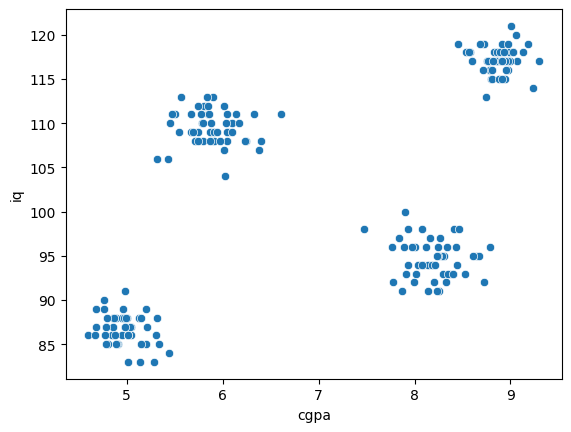

In [3]:
sns.scatterplot(x=df['cgpa'],y=df['iq'])

In [4]:
from sklearn.cluster import KMeans

In [5]:
wcss=[]
for i in range(1,10):
    kms=KMeans(n_clusters=i,verbose=1)
    kms.fit_predict(df)
    wcss.append(kms.inertia_)

Initialization complete
Iteration 0, inertia 70031.66879999998.
Iteration 1, inertia 29957.898287999997.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 8142.514200000001.
Iteration 1, inertia 4281.351804046069.
Iteration 2, inertia 4184.14127.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 4123.904.
Iteration 1, inertia 2366.2931033435825.
Iteration 2, inertia 2362.7133490000006.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 1034.238.
Iteration 1, inertia 682.7198650239623.
Iteration 2, inertia 681.96966.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 776.4261000000001.
Iteration 1, inertia 590.9824073272537.
Iteration 2, inertia 587.7764274703558.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 464.70910000000003.
Iteration 1, inertia 389.9748144495465.
Iteration 2, in

In [6]:
wcss

[29957.898287999997,
 4184.14127,
 2362.7133490000006,
 681.96966,
 587.7764274703558,
 388.8524026875981,
 359.6195623335395,
 273.6510757054303,
 217.13812758837264]

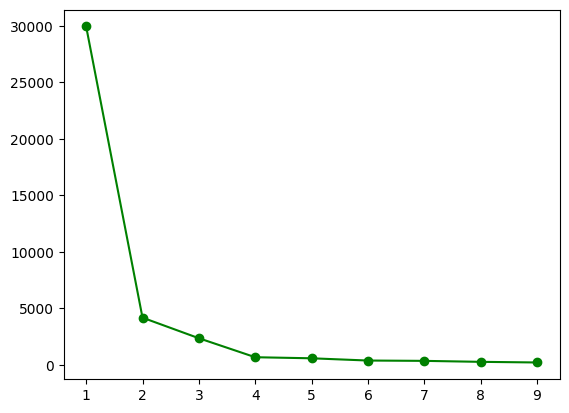

In [7]:
# Elbow curve
plt.plot(range(1,10),wcss,color="g",marker="o")

In [8]:
kms=KMeans(n_clusters=4)
lables=kms.fit_predict(df)

In [9]:
lables

array([1, 0, 3, 3, 0, 0, 3, 2, 0, 3, 1, 0, 3, 1, 0, 3, 0, 3, 0, 0, 3, 1,
       3, 1, 1, 3, 1, 2, 3, 0, 2, 0, 2, 0, 3, 3, 2, 0, 1, 0, 1, 3, 3, 1,
       2, 2, 3, 0, 2, 0, 1, 1, 2, 3, 2, 0, 0, 2, 0, 2, 0, 3, 3, 2, 1, 2,
       3, 1, 0, 3, 0, 2, 3, 1, 0, 2, 0, 2, 1, 3, 3, 2, 0, 1, 2, 1, 2, 0,
       2, 0, 2, 2, 3, 1, 3, 3, 2, 3, 1, 2, 0, 1, 1, 2, 1, 1, 3, 1, 2, 2,
       3, 2, 0, 0, 3, 2, 3, 0, 2, 1, 1, 0, 3, 2, 3, 1, 3, 0, 1, 3, 3, 0,
       1, 1, 0, 2, 0, 1, 3, 3, 3, 1, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 3, 0, 2, 0, 3, 1, 2, 0, 3, 2, 1, 0, 1, 1, 2, 2, 0, 2, 1, 1, 3,
       2, 0, 1, 2, 2, 0, 0, 0, 3, 1, 3, 3, 2, 0, 3, 3, 1, 1, 3, 1, 2, 0,
       0, 2], dtype=int32)

In [10]:
#df[lables==0]

In [11]:
#df[lables==1]

In [12]:
#df[lables==2]

In [13]:
#df[lables==3]

In [14]:
kms.cluster_centers_

array([[  5.8948, 109.52  ],
       [  4.9676,  86.7   ],
       [  8.8714, 117.16  ],
       [  8.1998,  94.6   ]])

In [15]:
X=df.iloc[:,:].values

In [16]:
X[lables==0,1]

array([113., 110., 109., 110., 110., 108., 111., 111., 113., 106., 112.,
       106., 108., 113., 108., 109., 108., 111., 109., 104., 111., 109.,
       109., 112., 111., 109., 108., 110., 109., 111., 108., 109., 109.,
       111., 112., 109., 111., 107., 111., 110., 108., 109., 110., 108.,
       108., 110., 107., 111., 112., 108.])

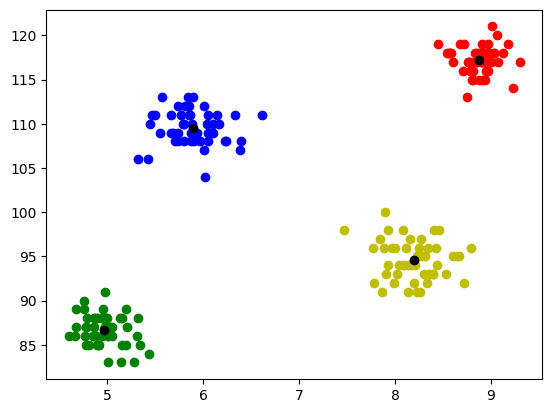

In [17]:
plt.scatter(X[lables==0,0],X[lables==0,1],color="b")
plt.scatter(X[lables==1,0],X[lables==1,1],color="g")
plt.scatter(X[lables==2,0],X[lables==2,1],color="r")
plt.scatter(X[lables==3,0],X[lables==3,1],color="y")
plt.scatter(kms.cluster_centers_[:,0],kms.cluster_centers_[:,1],color="k",label="Centroids")

In [18]:
df["target"]=lables

In [19]:
df

,cgpa,iq,target
0,5.13,88,1
1,5.90,113,0
2,8.36,93,3
3,8.27,97,3
4,5.45,110,0
...,...,...,...
195,4.68,89,1
196,8.57,118,2
197,5.85,112,0
198,6.23,108,0
